# Week 3 - #05 Sequential Model

[Sequential Model](https://www.coursera.org/learn/nlp-sequence-models) - [Understanding LSTM Network](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)

- ANN
- RNN
- LSTM
- GRU

# Assignment

Implement an LSTM for text generation and report the generated text samples.

Dataset: [10000 Vietnamese Books](https://www.kaggle.com/datasets/iambestfeeder/10000-vietnamese-books)

In [7]:
import os
import re
import string
import html
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from collections import Counter
from sklearn.model_selection import train_test_split

## Load dataset

In [2]:
folder_path = '/kaggle/input/10000-vietnamese-books/output'
books = []
book_names = []

for file_name in os.listdir(folder_path):
    book_names.append(file_name.split('.txt')[0])
    file_path = os.path.join(folder_path, file_name)
    with open(file_path, 'r', encoding='utf-8') as file:
        books.append(file.read())

In [3]:
print('Book name: "', book_names[0], '"')
print(books[0])

Book name: " Nhà ảo thuật - Mạc Can "

Mạc Can
Nhà ảo thuật
Có một cậu bé muốn học vài trò ảo thuật nhưng không tìm đâu ra trường và thầy dạy. Một hôm rỗi rảnh, người cha chở cậu con trai nhỏ xíu, khoảng 10 tuổi, ngồi háo hức sau yên xe Honda. Vòng quanh đường phố một lúc, đang bình thường thì tự nhiên chiếc xe khục khịch ho khan, dừng lại đầu hẻm như là có hẹn trước, ngay chóc tiệm thuốc tây và cái tủ bán thuốc lá. Nhưng sau cái quầy trong tiệm, và trên chiếc ghế thấp nơi tủ thuốc lá đặt nhờ ngoài hè đường, không có người bán hàng nào. Còn lạ hơn là mọi người, trong đó có ông cha cố (ông thích đi bộ, thường ngày vẫn đi bộ và bây giờ cũng vậy, đang mỉm cười đếm bước). Cha vẫy tay chào những người khác đang chạy xe quanh đó, dù họ đi hay chạy mà tới “giới hạn” này, tức khoảng đường có tủ thuốc lá thì ai cũng... mờ đi và mất tiêu. Cha cố vẫn nghe người ta nói với ông rằng thỉnh thoảng cha cũng... biến mất, khi đó ông lại mỉm cười đồng ý. Cha có quen với “nhà ảo thuật” và cha cũng thích x

### Problems in corpus:

- header, footer *(Example: header includes author, book's name again; footer is usually in format beginning with "Mục lục")*.
- appear **"&quot ;"** (html decode) in text.
- the book content has splitted almost by "."

In [4]:
print(len(books))

10415


## Preprocess text

In [5]:
# remove header: author, book's name
for i in range(len(books)):
    header = book_names[i].split(' - ')
    if len(header) == 2:
        author = header[1]
        book_name = header[0]
        books[i] = books[i].replace(author, '')
        books[i] = books[i].replace(book_name, '')
print(books[0])
del book_names




Có một cậu bé muốn học vài trò ảo thuật nhưng không tìm đâu ra trường và thầy dạy. Một hôm rỗi rảnh, người cha chở cậu con trai nhỏ xíu, khoảng 10 tuổi, ngồi háo hức sau yên xe Honda. Vòng quanh đường phố một lúc, đang bình thường thì tự nhiên chiếc xe khục khịch ho khan, dừng lại đầu hẻm như là có hẹn trước, ngay chóc tiệm thuốc tây và cái tủ bán thuốc lá. Nhưng sau cái quầy trong tiệm, và trên chiếc ghế thấp nơi tủ thuốc lá đặt nhờ ngoài hè đường, không có người bán hàng nào. Còn lạ hơn là mọi người, trong đó có ông cha cố (ông thích đi bộ, thường ngày vẫn đi bộ và bây giờ cũng vậy, đang mỉm cười đếm bước). Cha vẫy tay chào những người khác đang chạy xe quanh đó, dù họ đi hay chạy mà tới “giới hạn” này, tức khoảng đường có tủ thuốc lá thì ai cũng... mờ đi và mất tiêu. Cha cố vẫn nghe người ta nói với ông rằng thỉnh thoảng cha cũng... biến mất, khi đó ông lại mỉm cười đồng ý. Cha có quen với “nhà ảo thuật” và cha cũng thích xem ông diễn.Chỗ đó ngược sáng hay ánh sáng bị khúc xạ chă

In [6]:
def normalize(text):
    # lowercase
    text = text.lower()

    # remove all text from "Mục lục" position
    index = text.find('mục lục')
    text = text[:index] if index != -1 else text
    # remove "dịch giả", "dịch", "diễn nôm"
    pattern = r'.*?(dịch giả|dịch giả:|dịch|diễn nôm).*?(?:[.!?]|$)'
    text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    # decode html entities
    text = html.unescape(text)
    
    # remove html tags
    text = re.sub(r'<[^>]*>', ' ', text)
    # remove http
    text = re.sub(r'Nguồn:\s*http?:\/\/\S+', ' ', text)
    text = re.sub(r'http\S*', ' ', text)
    # remove punctuation
    punctuation = string.punctuation + '“”'
    text = re.sub(f"[{punctuation}₫—℅\d\n\t]", ' ', text)
    # remove –
    text = re.sub(r'–\s', ' ', text)
    # remove extra white spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text
        

In [7]:
sample = normalize(books[0])
print(sample)

có một cậu bé muốn học vài trò ảo thuật nhưng không tìm đâu ra trường và thầy dạy một hôm rỗi rảnh người cha chở cậu con trai nhỏ xíu khoảng tuổi ngồi háo hức sau yên xe honda vòng quanh đường phố một lúc đang bình thường thì tự nhiên chiếc xe khục khịch ho khan dừng lại đầu hẻm như là có hẹn trước ngay chóc tiệm thuốc tây và cái tủ bán thuốc lá nhưng sau cái quầy trong tiệm và trên chiếc ghế thấp nơi tủ thuốc lá đặt nhờ ngoài hè đường không có người bán hàng nào còn lạ hơn là mọi người trong đó có ông cha cố ông thích đi bộ thường ngày vẫn đi bộ và bây giờ cũng vậy đang mỉm cười đếm bước cha vẫy tay chào những người khác đang chạy xe quanh đó dù họ đi hay chạy mà tới giới hạn này tức khoảng đường có tủ thuốc lá thì ai cũng mờ đi và mất tiêu cha cố vẫn nghe người ta nói với ông rằng thỉnh thoảng cha cũng biến mất khi đó ông lại mỉm cười đồng ý cha có quen với nhà ảo thuật và cha cũng thích xem ông diễn chỗ đó ngược sáng hay ánh sáng bị khúc xạ chăng chưa phải hẳn một bác xích lô ngồi t

In [8]:
import time

# Normalize the first 100 books for training data
data = []
start_time = time.time()
book_num = 0
for corpus in books[:100]:
    t = time.time()
    data.append(normalize(corpus))
    print(f"Successfully normalize book: {book_num + 1}. Time: {(time.time() - t):.4f}s. Total: {(time.time() - start_time):.4f}s")
    book_num += 1
    t = time.time()
print(f"Total time for 100 books: {((time.time() - start_time))}s.")

Successfully normalize book: 1. Time: 1.0132s. Total: 1.0133s
Successfully normalize book: 2. Time: 1.4806s. Total: 2.4940s
Successfully normalize book: 3. Time: 4.2151s. Total: 6.7091s
Successfully normalize book: 4. Time: 0.1158s. Total: 6.8250s
Successfully normalize book: 5. Time: 31.6709s. Total: 38.4959s
Successfully normalize book: 6. Time: 3.6901s. Total: 42.1861s
Successfully normalize book: 7. Time: 0.3139s. Total: 42.5001s
Successfully normalize book: 8. Time: 0.3200s. Total: 42.8202s
Successfully normalize book: 9. Time: 12.6048s. Total: 55.4251s
Successfully normalize book: 10. Time: 1.6296s. Total: 57.0547s
Successfully normalize book: 11. Time: 0.7203s. Total: 57.7750s
Successfully normalize book: 12. Time: 26.8277s. Total: 84.6028s
Successfully normalize book: 13. Time: 4.7967s. Total: 89.3995s
Successfully normalize book: 14. Time: 110.6124s. Total: 200.0119s
Successfully normalize book: 15. Time: 0.7454s. Total: 200.7573s
Successfully normalize book: 16. Time: 7.9450s

In [9]:
import json
with open("/kaggle/working/dat_book_chunk1.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False)

In [10]:
print(len(data))

100


## Character-level Generation

- Using one corpus only (`data[0]`) for this task.

In [11]:
with open('/kaggle/working/dat_book_chunk1.json', 'r', encoding='utf-8') as file:
    data = json.loads(file.read())

In [12]:
text = data[0]

In [13]:
print(text)

có một cậu bé muốn học vài trò ảo thuật nhưng không tìm đâu ra trường và thầy dạy một hôm rỗi rảnh người cha chở cậu con trai nhỏ xíu khoảng tuổi ngồi háo hức sau yên xe honda vòng quanh đường phố một lúc đang bình thường thì tự nhiên chiếc xe khục khịch ho khan dừng lại đầu hẻm như là có hẹn trước ngay chóc tiệm thuốc tây và cái tủ bán thuốc lá nhưng sau cái quầy trong tiệm và trên chiếc ghế thấp nơi tủ thuốc lá đặt nhờ ngoài hè đường không có người bán hàng nào còn lạ hơn là mọi người trong đó có ông cha cố ông thích đi bộ thường ngày vẫn đi bộ và bây giờ cũng vậy đang mỉm cười đếm bước cha vẫy tay chào những người khác đang chạy xe quanh đó dù họ đi hay chạy mà tới giới hạn này tức khoảng đường có tủ thuốc lá thì ai cũng mờ đi và mất tiêu cha cố vẫn nghe người ta nói với ông rằng thỉnh thoảng cha cũng biến mất khi đó ông lại mỉm cười đồng ý cha có quen với nhà ảo thuật và cha cũng thích xem ông diễn chỗ đó ngược sáng hay ánh sáng bị khúc xạ chăng chưa phải hẳn một bác xích lô ngồi t

In [14]:
chars = sorted(list(set(text)))
char_to_int = dict((c, i) for i, c in enumerate(chars))

# summarize the loaded data
n_chars = len(text)
n_vocab = len(chars)
print("Total Characters:", n_chars) 
print("Total Vocab:", n_vocab)
print(chars)

Total Characters: 10045
Total Vocab: 88
[' ', 'a', 'b', 'c', 'd', 'e', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'à', 'á', 'â', 'ã', 'è', 'é', 'ê', 'ì', 'í', 'ò', 'ó', 'ô', 'õ', 'ù', 'ú', 'ý', 'ă', 'đ', 'ĩ', 'ũ', 'ơ', 'ư', 'ạ', 'ả', 'ấ', 'ầ', 'ẩ', 'ẫ', 'ậ', 'ắ', 'ằ', 'ẳ', 'ặ', 'ẹ', 'ẻ', 'ẽ', 'ế', 'ề', 'ể', 'ễ', 'ệ', 'ỉ', 'ị', 'ọ', 'ỏ', 'ố', 'ồ', 'ổ', 'ỗ', 'ộ', 'ớ', 'ờ', 'ở', 'ỡ', 'ợ', 'ụ', 'ủ', 'ứ', 'ừ', 'ử', 'ữ', 'ự', 'ỳ', 'ỹ']


In [15]:
# prepare the dataset of input to output pairs encoded as integers
seq_length = 50
step = 1
dataX = []
dataY = []
for i in range(0, n_chars - seq_length, step):
    seq_in = text[i:i + seq_length]
    seq_out = text[i + seq_length] 
    dataX.append([char_to_int[char] for char in seq_in]) 
    dataY.append(char_to_int[seq_out])
n_patterns = len(dataX)
print("Total Patterns: ", n_patterns)

Total Patterns:  9995


In [16]:
# Tensor conversion
X = torch.tensor(dataX, dtype=torch.long)  # use for embedding / crossentropy
y = torch.tensor(dataY, dtype=torch.long)
print(X.shape, y.shape)

torch.Size([9995, 50]) torch.Size([9995])


In [17]:
class CharModel(nn.Module): 
    def __init__(self, vocab_size, hidden_size=256, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 128)
        self.lstm = nn.LSTM(
            input_size=128, hidden_size=hidden_size, 
            num_layers=num_layers, batch_first=True, dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x):
        x = self.embedding(x)  # (batch, seq, embed_dim)
        x, _ = self.lstm(x)
        x = x[:, -1, :]    # take only the last output
        x = self.linear(self.dropout(x))  # produce output
        return x

In [18]:
from torch.utils.data import DataLoader, TensorDataset
n_epochs = 50
batch_size = 32 

model = CharModel(n_vocab)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 
print(f"Device: {device}")
model.to(device)

optimizer = optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss(reduction="mean")
loader = DataLoader(TensorDataset(X, y), shuffle=True, batch_size=batch_size)

best_model = None
best_loss = np.inf
for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch.to(device))
        loss = loss_fn(y_pred, y_batch.to(device)) 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Validation
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)

    if avg_loss < best_loss:
        best_loss = total_loss
        best_model = model.state_dict()
        
    print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}")

Device: cuda:0
Epoch 1/50 | Loss: 2.0885
Epoch 2/50 | Loss: 1.7988
Epoch 3/50 | Loss: 1.6706
Epoch 4/50 | Loss: 1.5599
Epoch 5/50 | Loss: 1.4910
Epoch 6/50 | Loss: 1.4221
Epoch 7/50 | Loss: 1.3767
Epoch 8/50 | Loss: 1.3136
Epoch 9/50 | Loss: 1.2595
Epoch 10/50 | Loss: 1.1850
Epoch 11/50 | Loss: 1.1162
Epoch 12/50 | Loss: 1.0292
Epoch 13/50 | Loss: 0.9718
Epoch 14/50 | Loss: 0.8944
Epoch 15/50 | Loss: 0.8303
Epoch 16/50 | Loss: 0.7407
Epoch 17/50 | Loss: 0.6625
Epoch 18/50 | Loss: 0.5826
Epoch 19/50 | Loss: 0.5037
Epoch 20/50 | Loss: 0.4417
Epoch 21/50 | Loss: 0.3799
Epoch 22/50 | Loss: 0.3264
Epoch 23/50 | Loss: 0.2875
Epoch 24/50 | Loss: 0.2448
Epoch 25/50 | Loss: 0.2047
Epoch 26/50 | Loss: 0.1866
Epoch 27/50 | Loss: 0.1535
Epoch 28/50 | Loss: 0.1342
Epoch 29/50 | Loss: 0.1217
Epoch 30/50 | Loss: 0.1067
Epoch 31/50 | Loss: 0.0943
Epoch 32/50 | Loss: 0.0800
Epoch 33/50 | Loss: 0.0717
Epoch 34/50 | Loss: 0.0696
Epoch 35/50 | Loss: 0.0618
Epoch 36/50 | Loss: 0.0570
Epoch 37/50 | Loss: 0.

In [19]:
torch.save({
    "model_state": best_model,
    "char_to_int": char_to_int
}, "/kaggle/working/single-char.pth")

In [20]:
# ===== Text Generation =====
model.load_state_dict(best_model)
model.eval()

# randomly generate a prompt
start = np.random.randint(0, len(text)-seq_length)
prompt = text[start:start+seq_length]
pattern = [char_to_int[c] for c in prompt]
int_to_char = dict((i, c) for c, i in char_to_int.items())

print('Prompt: "%s"' % prompt) 
generated = []

with torch.no_grad():
    for _ in range(500):
        x = torch.tensor([pattern], dtype=torch.long).to(device)
        prediction = model(x)
        index = int(prediction.argmax())
        result = int_to_char[index]
        generated.append(result)
        # update sequence
        pattern.append(index)
        pattern = pattern[1:]

print("Generated text:")
print("".join(generated))
print()
print("Done.")

Prompt: " này trong vòng bảy con số có gì mà suy nghĩ nhiều"
Generated text:
 tiền ấy à hiện ra thì có gì khó nhưng nó lại có có không không vì nó là tiền một vật thể rờ đụng nhưng đầy bất trắc mà ngày nay người ta gọi là ảo có đó rồi cũng mất đó trong xóm nhà thờ này rất nhiều người nói vậy vịn vào trường hợp nhà ảo thuật họ nói thêm rằng ông già ấy làm nhiều trò rất hay một tờ giấy trắng nhé xếp lại làm tư bằng khổ của tờ năm trăm ngàn mở ra thì tờ giấy biến mất tờ giấy thành tiền được không cách hỏi khó chịu như hỏi một nhà luyện kim ông luyện kim ông nấu cát thành và

Done.


## Word-level Generation

- Using all 100 corpus in data

In [21]:
with open('/kaggle/working/dat_book_chunk1.json', 'r', encoding='utf-8') as file:
    data = json.loads(file.read())

In [22]:
all_text = " ".join(data)
words = all_text.split()
word_counts = Counter(words)

vocab = list(word_counts.keys())
vocab_size = len(vocab)
word_to_int = {word: i for i, word in enumerate(vocab)}
int_to_word = {i: word for word, i in word_to_int.items()}

print(f"Total vocab: {vocab_size}")
print(f"Total words: {len(all_text)}")

Total vocab: 13823
Total words: 8920152


In [23]:
class TextDataset(Dataset):
    def __init__(self, words, seq_len=30):
        self.seq_len = seq_len
        self.data = [word_to_int[w] for w in words]

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        X = torch.tensor(self.data[idx:idx+self.seq_len])
        y = torch.tensor(self.data[idx+1:idx+self.seq_len+1])
        return X, y
dataset = TextDataset(words, seq_len=50)

In [4]:
class WordLevelGenerationLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

class EarlyStopping:
    def __init__(self, patience=3, delta=0.0):
        self.patience = patience
        self.counter = 0
        self.best_loss = np.inf
        self.delta = delta
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

class LRScheduler:
    def __init__(self, optimizer, factor=0.5, patience=2, min_lr=1e-6):
        self.optimizer = optimizer
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.counter = 0
        self.best_loss = np.inf

    def __call__(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                for param_group in self.optimizer.param_groups:
                    new_lr = max(param_group['lr'] * self.factor, self.min_lr)
                    print(f"Reducing LR to {new_lr}")
                    param_group['lr'] = new_lr
                self.counter = 0

In [25]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [26]:
epochs = 20
batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

model = WordLevelGenerationLSTM(vocab_size)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

early_stopping = EarlyStopping(patience=5)
lr_scheduler = LRScheduler(optimizer)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 
print(f"Device: {device}")
model.to(device)

train_losses = []
val_losses = []
best_model = None
best_loss = np.inf
start_time = time.time()
for epoch in range(epochs):
    # ---- Train ----
    model.train()
    total_loss = 0
    for X_batch, y_batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{epochs}"):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred, _ = model(X_batch)
        loss = loss_fn(y_pred.reshape(-1, vocab_size), y_batch.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # ---- Validation ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred, _ = model(X_batch)
            loss = loss_fn(y_pred.reshape(-1, vocab_size), y_batch.reshape(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Save best model
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_model = model.state_dict()
        torch.save({
            "model_state": best_model,
            "word_to_int": word_to_int
        }, "/kaggle/working/single-word.pth")

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    lr_scheduler(avg_val_loss)
    early_stopping(avg_val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break
print()
print(f"Total train time: {time.time() - start_time}")

Device: cuda:0


Train Epoch 1/20: 100%|██████████| 3216/3216 [07:22<00:00,  7.26it/s]


Epoch 1/20 | Train Loss: 5.4138 | Val Loss: 4.8974


Train Epoch 2/20: 100%|██████████| 3216/3216 [07:22<00:00,  7.27it/s]


Epoch 2/20 | Train Loss: 4.7182 | Val Loss: 4.5803


...

Epoch 18/20 | Train Loss: 3.8045 | Val Loss: 3.8307


Train Epoch 19/20: 100%|██████████| 3216/3216 [07:24<00:00,  7.23it/s]


Epoch 19/20 | Train Loss: 3.7956 | Val Loss: 3.8222


Train Epoch 20/20: 100%|██████████| 3216/3216 [07:24<00:00,  7.23it/s]


Epoch 20/20 | Train Loss: 3.7878 | Val Loss: 3.8164

Total train time: 9831.333555459976


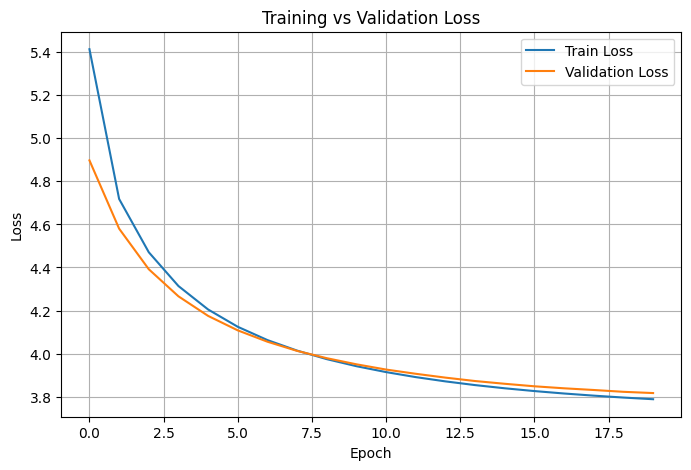

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("../src/models/single-word.pth", map_location=device)
best_model_state = checkpoint["model_state"]
word_to_int = checkpoint["word_to_int"]
int_to_word = {i: w for w, i in word_to_int.items()}
vocab_size = len(word_to_int)

In [ ]:
model = WordLevelGenerationLSTM(vocab_size=vocab_size, embed_dim=128, hidden_dim=256, num_layers=1)
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [11]:
def generate(model, start_words, max_len=50, temperature=1.0, seq_len=30):
    model.eval()
    words = start_words.split()
    state = None

    for _ in range(max_len):
        x = torch.tensor([[word_to_int.get(w, 0) for w in words[-seq_len:]]],
                         dtype=torch.long).to(device)
        out, state = model(x, state)
        logits = out[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1).detach().cpu().numpy()[0]
        next_id = random.choices(range(vocab_size), weights=probs)[0]
        words.append(int_to_word[next_id])
    return " ".join(words)

print(generate(model, "cậu bé", 100, temperature=0.8, seq_len=50))

cậu bé rối rít khe khẽ rón rén quì sụp aó roi bàn tay vừa run run tôi chạy nhanh đến cạnh cô nhắm nghiền mắt nhìn tôi không muốn nói là tôi thấy chóng mặt mà người tôi tôi sống ở lại huế tân khách chơi kịch này quá tôi buông nó ra ngoài cửa sổ adam nói không được nữa sao anh lại nghĩ là em sẽ phải làm sao tránh khỏi khập khiễng đi bắt người đàn bà cô cao lớn ngồi đây với một chút tình nguyện lắm anh xin phép để cho em thức ăn cho laura
